# **Customer Segmentation with K-means**
 **Goal:** discover groups of wholesale customers with similar annual purchasing behaviour, and describe offers the distributor could explore for each group. This is an exploratory unsupervised learning project; there is no target label to predict.

**Dataset:** UCI Wholesale Customers, 440 customers. Six columns record annual spending in monetary units. Channel identifies hotels/restaurants/cafés (1) or retail shops (2); Region identifies Lisbon (1), Oporto (2), or other areas (3). These category codes are retained for interpretation but excluded from clustering.
We fit the available customers together to explore segments. This notebook does not measure generalisation to future customers or business impact.

## Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Download and explore the dataset

In [ ]:
import requests
url = "https://archive.ics.uci.edu/static/public/292/wholesale+customers.zip"
response = requests.get(url)
with open("/content/wholesale+customers.zip", "wb") as f:
    f.write(response.content)


In [ ]:
df = pd.read_csv('/content/wholesale+customers.zip')
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


## Select clustering features
Use only the six spending columns. Channel and Region describe business type and location; leaving them out lets us discover purchasing patterns independently of those categories.

In [ ]:
spending = df[["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]]

## Plot original spending
Histograms show how many customers fall within each spending range.

array([[<Axes: title={'center': 'Fresh'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>]], dtype=object)

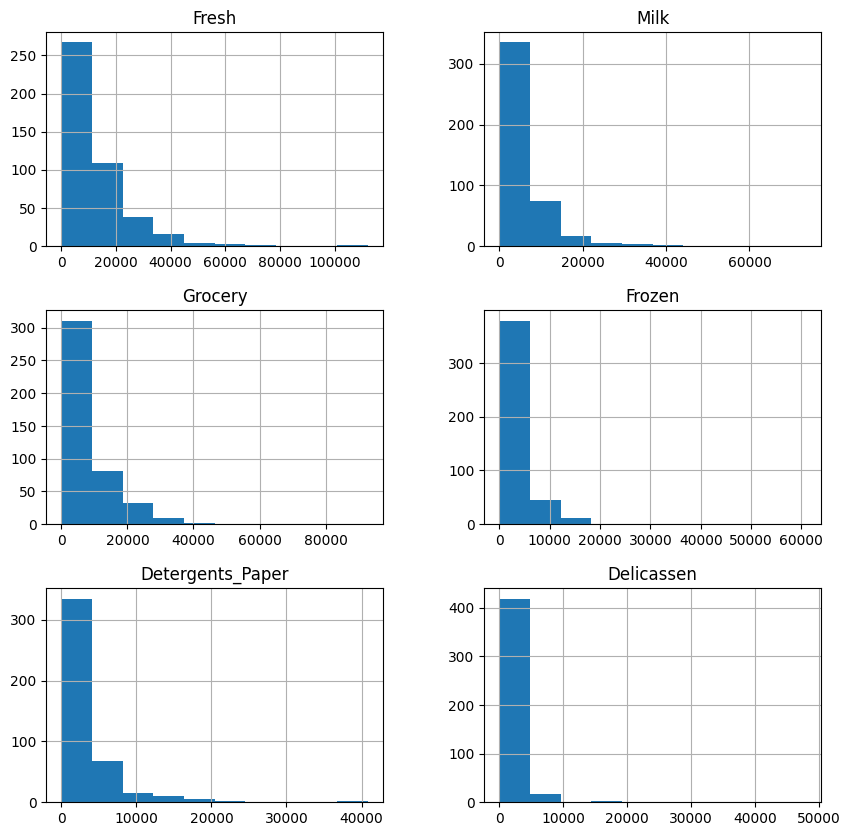

In [ ]:
spending.hist(figsize=(10,10))

In [ ]:
spending_r = np.log1p(spending)

array([[<Axes: title={'center': 'Fresh'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>]], dtype=object)

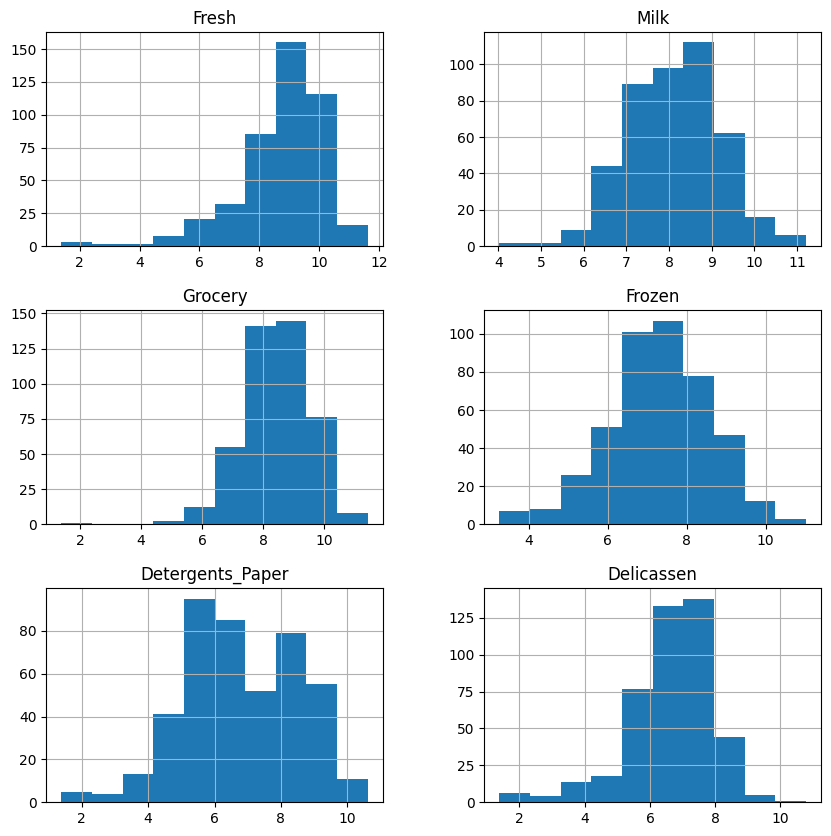

In [ ]:
spending_r.hist(figsize=(10, 10))

array([[<Axes: title={'center': 'Fresh'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>]], dtype=object)

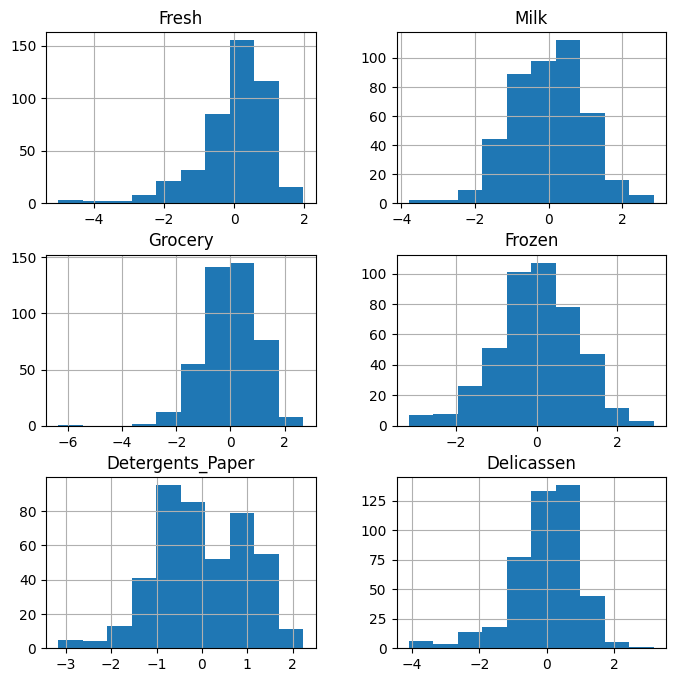

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

spending_scaled = pd.DataFrame(
    scaler.fit_transform(spending_r),
    columns=spending_r.columns,
    index=spending_r.index
)

spending_scaled.hist(figsize=(8, 8))

## Compare candidate cluster counts
Fit K-means for k=2 through 10 and compare average silhouette scores on the same six-dimensional data.

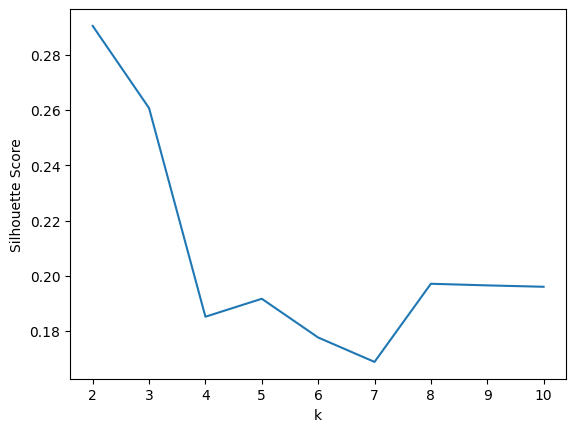

In [ ]:
from scipy.spatial.distance import euclidean
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

models = []
scores = []

for k in range(2, 11):

  model = KMeans(n_clusters=k, random_state=42, n_init='auto')
  model.fit(spending_scaled)
  models.append(model)

  score = silhouette_score(spending_scaled, model.labels_, metric=euclidean)
  scores.append(score)

plt.plot(range(2, 11), scores)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

## Visualise two candidate models

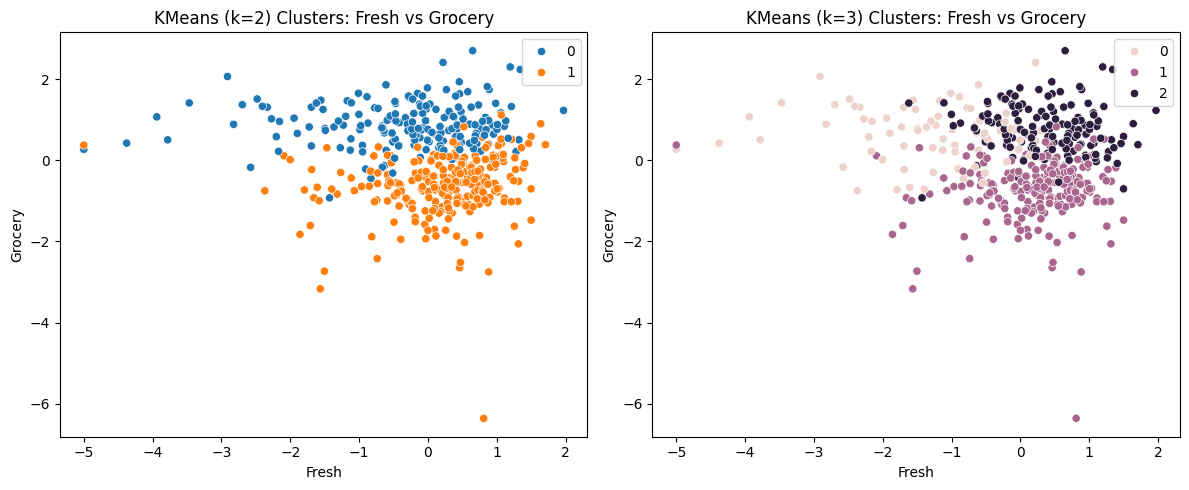

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=spending_scaled, x='Fresh', y='Grocery', hue=models[0].labels_, ax=ax[0])
ax[0].set_title(f'KMeans (k=2) Clusters: Fresh vs Grocery')

sns.scatterplot(data=spending_scaled, x='Fresh', y='Grocery', hue=models[1].labels_, ax=ax[1])
ax[1].set_title(f'KMeans (k=3) Clusters: Fresh vs Grocery')

plt.tight_layout()
plt.show()

## Count the two-cluster groups
Retrieve the first candidate model (k=2) and count customers in each group.

In [ ]:
model_k2 = models[0]

cluster_counts = pd.Series(model_k2.labels_).value_counts().sort_index()
print(cluster_counts)

0    187
1    253
Name: count, dtype: int64


Create a copy of the original customer table. This allows cluster labels to be attached without changing the original dataset

In [ ]:
customer_segments = df.copy()
customer_segments

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


Add one label per customer in the same row order. The Cluster column is an output for analysis and must not be added to the clustering features.

In [ ]:
customer_segments['Cluster'] = model_k2.labels_
customer_segments

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,0
...,...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204,1
436,1,3,39228,1431,764,4510,93,2346,1
437,2,3,14531,15488,30243,437,14841,1867,0
438,1,3,10290,1981,2232,1038,168,2125,1


Describe typical spending for k=2

In [ ]:
customer_segments.groupby("Cluster")[spending.columns].median()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,5396.0,7677.0,11522.0,1057.0,4508.0,1386.0
1,10405.0,1882.0,2406.0,2234.0,325.0,750.0


## Compare clusters with business types
Count Channel categories within each cluster. Channel was excluded from training; this comparison helps interpret the groups and assess how closely they resemble already known business types.

In [ ]:
pd.crosstab(customer_segments['Cluster'], customer_segments['Channel'])

Channel,1,2
Cluster,,
0,53,134
1,245,8


## Examine the three-cluster alternative

In [ ]:
# Retrieve the fitted k=3 model
model_k3 = models[1]

# Keep original spending amounts and add cluster assignments
customer_segments_k3 = df.copy()
customer_segments_k3["Cluster"] = model_k3.labels_

# Compare median spending across the three clusters
display(
    customer_segments_k3.groupby("Cluster")[spending.columns].median()
)

# Count business types within each cluster
display(
    pd.crosstab(
        customer_segments_k3["Cluster"],
        customer_segments_k3["Channel"]
    )
)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,1406.0,6154.0,10471.0,364.0,4167.0,436.0
1,9784.5,1626.0,2175.5,2151.0,274.5,703.5
2,11594.0,7243.0,10685.0,2005.0,3537.0,2005.0


Channel,1,2
Cluster,,
0,34,47
1,213,3
2,51,92


## Inspect spending variation within groups
Calculate the 25th percentile, median, and 75th percentile for each category. The interval between the quartiles describes roughly the middle 50% of spending values. These summaries belong to the initial k=3 model, not the later final model.

In [ ]:
spending_summary_k3 = (
    customer_segments_k3
    .groupby("Cluster")[spending.columns]
    .quantile([0.25, 0.50, 0.75])
)

spending_summary_k3.index.names = ["Cluster", "Percentile"]
display(spending_summary_k3)

Fresh     Milk   Grocery   Frozen  Detergents_Paper  \
Cluster Percentile                                                          
0       0.25          444.0   3648.0   6114.00   145.00           1566.00   
        0.50         1406.0   6154.0  10471.00   364.00           4167.00   
        0.75         3087.0   8675.0  14682.00   787.00           6907.00   
1       0.25         5318.5   1012.0   1497.25   913.75            139.75   
        0.50         9784.5   1626.0   2175.50  2151.00            274.50   
        0.75        16992.0   2705.5   3252.75  4104.00            549.25   
2       0.25         5540.5   4984.5   6980.50  1062.50           1539.50   
        0.50        11594.0   7243.0  10685.00  2005.00           3537.00   
        0.75        22355.5  12185.0  16625.00  4527.00           6647.00   

                    Delicassen  
Cluster Percentile              
0       0.25            142.00  
        0.50            436.00  
        0.75           1080.00  
1       0.25            377.25  
        0.50            703.50  
        0.75           1173.75  
2       0.25           1163.00  
        0.50           2005.00  
        0.75           2996.00

## Check sensitivity to starting centres
Repeat k=3 across five seeds with ten initialisations per run. ARI compares the resulting assignments with the original k=3 candidate, ignoring permutations of cluster IDs. Recorded ARI values of 0.944–0.956 show similar groupings. This checks starting-point sensitivity, not stability across different customer samples.

In [ ]:
from sklearn.metrics import adjusted_rand_score

results = []
reference_labels = model_k3.labels_

for seed in [0, 1, 2, 10, 42]:
    candidate = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=10
    )
    labels = candidate.fit_predict(spending_scaled)

    results.append({
        "Seed": seed,
        "Silhouette": silhouette_score(spending_scaled, labels),
        "ARI_vs_original": adjusted_rand_score(reference_labels, labels)
    })

stability_results = pd.DataFrame(results)
display(stability_results.round(3))

,Seed,Silhouette,ARI_vs_original
0,0,0.259,0.950
1,1,0.258,0.956
2,2,0.259,0.950
3,10,0.259,0.949
4,42,0.259,0.944


## Fit and describe the final model

In [ ]:
# Fit the final model
final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
final_model.fit(spending_scaled)

# Attach its labels to a copy of the original data
final_segments = df.copy()
final_segments["Cluster"] = final_model.labels_

# Updated customer counts
display(final_segments["Cluster"].value_counts().sort_index())

# Updated median spending
display(final_segments.groupby("Cluster")[spending.columns].median())

# Updated business-type counts
display(pd.crosstab(final_segments["Cluster"], final_segments["Channel"]))

# Final silhouette score
print(
    "Silhouette score:",
    round(silhouette_score(spending_scaled, final_model.labels_), 3)
)

,count
Cluster,
0,80
1,147
2,213


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,1492.5,6300.5,10502.5,376.0,4217.5,434.5
1,12126.0,7184.0,9965.0,2005.0,3378.0,2005.0
2,9612.0,1601.0,2155.0,2121.0,274.0,686.0


Channel,1,2
Cluster,,
0,32,48
1,56,91
2,210,3


Silhouette score: 0.259


## Save the model and preprocessing

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import joblib

model_path = "/content/drive/MyDrive/customer_segmentation.joblib"

model_bundle = {
    "model": final_model,
    "scaler": scaler,
    "features": spending.columns.tolist(),
    "transformation": "log1p"
}

joblib.dump(model_bundle, model_path)

Mounted at /content/drive


['/content/drive/MyDrive/customer_segmentation.joblib']

## Reload and verify assignments

In [ ]:
loaded = joblib.load(model_path)

# Repeat the original preprocessing in the same column order
saved_features = df[loaded["features"]]
saved_log = np.log1p(saved_features)
saved_scaled = loaded["scaler"].transform(saved_log)

# Preserve the feature names used when fitting K-means
saved_scaled = pd.DataFrame(
    saved_scaled,
    columns=loaded["features"],
    index=df.index
)

reloaded_labels = loaded["model"].predict(saved_scaled)

print("Assignments match:",
      np.array_equal(reloaded_labels, final_model.labels_))

Assignments match: True


## **Summary**
This project groups **440 wholesale customers by their purchasing behaviour** using K-means. I used six spending features, applied a log transformation to reduce skew, and standardised them before clustering.

I compared different cluster counts and selected **three groups** for their useful descriptions: grocery and household products, broad product spending, and fresh/frozen food. The final silhouette score was **0.259**, showing some overlap, while repeated runs produced similar groups.

I saved the model with its preprocessing and confirmed that reloading reproduced the same assignments. These segments could help explore tailored product offers, although their business impact has not been tested.